Using device: cpu

Total Samples: 11949

Classes Found:
['agitation', 'background', 'clustering', 'normal']

Encoded Classes
0 agitation
1 background
2 clustering
3 normal

Class Distribution
agitation: 1140
background: 1500
clustering: 1260
normal: 8049

Train: 8603
Validation: 956
Test: 2390

Class Weights
tensor([1.6185, 1.4112, 1.5399, 0.6092])

Training...

Epoch 01/50 | Loss=0.8366 | Val F1=0.8023
Epoch 02/50 | Loss=0.7158 | Val F1=0.8032
Epoch 03/50 | Loss=0.6729 | Val F1=0.8535
Epoch 04/50 | Loss=0.6600 | Val F1=0.8503
Epoch 05/50 | Loss=0.6439 | Val F1=0.8647
Epoch 06/50 | Loss=0.6285 | Val F1=0.9009
Epoch 07/50 | Loss=0.6103 | Val F1=0.8948
Epoch 08/50 | Loss=0.5953 | Val F1=0.8129
Epoch 09/50 | Loss=0.5873 | Val F1=0.8990
Epoch 10/50 | Loss=0.5733 | Val F1=0.9037
Epoch 11/50 | Loss=0.5752 | Val F1=0.8686
Epoch 12/50 | Loss=0.5603 | Val F1=0.8791
Epoch 13/50 | Loss=0.5523 | Val F1=0.8931
Epoch 14/50 | Loss=0.5430 | Val F1=0.8945
Epoch 15/50 | Loss=0.5234 | Val F1=0.9189
Epoch

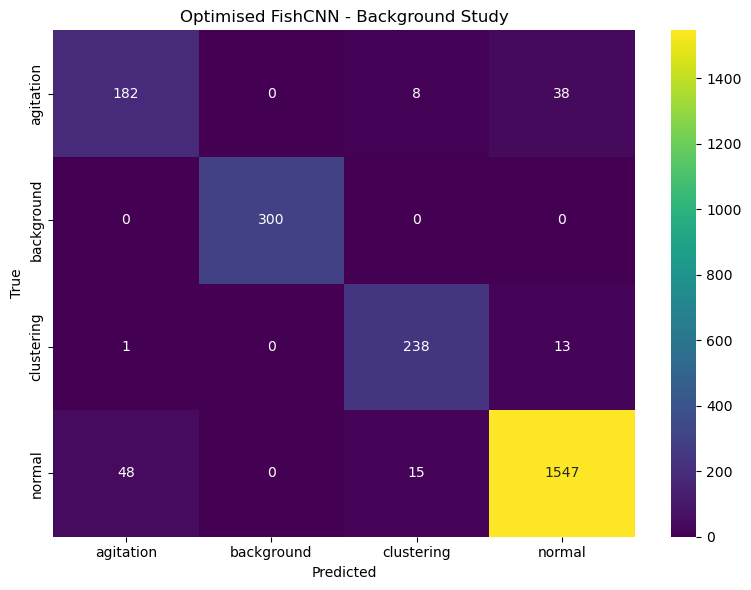


Saved:
fishcnn_background_results.csv
fishcnn_background_salmon.pth
fishcnn_background_cm.png


In [1]:
import os
import time
import copy

import librosa
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    Dataset,
    DataLoader
)

# =====================================================
# CONFIG
# =====================================================

DATASET_PATH = "/media/feliciano/Aux/AI_AFS_DATASET/behavior_dataset"

SAMPLE_RATE = 16000
N_MELS = 128
FMAX = 4000

BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1e-3

PATIENCE = 10

DEVICE = "cpu"

print("Using device:", DEVICE)

# =====================================================
# OPTIMISED FISHCNN
# =====================================================

class FishCNN_Optimized(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.block1 = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                32,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(2)
        )

        self.block2 = nn.Sequential(

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                64,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(2)
        )

        self.block3 = nn.Sequential(

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                128,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(2)
        )

        self.gap = nn.AdaptiveAvgPool2d((4, 4))

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 4 * 4,
                256
            ),

            nn.BatchNorm1d(256),

            nn.ReLU(inplace=True),

            nn.Dropout(0.40),

            nn.Linear(
                256,
                128
            ),

            nn.BatchNorm1d(128),

            nn.ReLU(inplace=True),

            nn.Dropout(0.30),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x):

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        x = self.gap(x)

        x = self.classifier(x)

        return x

# =====================================================
# MEL EXTRACTION
# =====================================================

def extract_mel(path):

    signal, sr = librosa.load(
        path,
        sr=SAMPLE_RATE,
        mono=True
    )

    mel = librosa.feature.melspectrogram(
        y=signal,
        sr=sr,
        n_mels=N_MELS,
        fmax=FMAX
    )

    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    return mel_db.astype(np.float32)

# =====================================================
# LABEL MAPPING
# =====================================================

def map_label_from_path(path):

    p = path.lower()

    if "background" in p:
        return "background"

    if "normal" in p:
        return "normal"

    if "clustering" in p:
        return "clustering"

    if "agitation" in p:
        return "agitation"

    return None

# =====================================================
# LOAD DATASET
# =====================================================

files = []
labels = []

for root, dirs, fs in os.walk(DATASET_PATH):

    for f in fs:

        if f.lower().endswith(".wav"):

            full_path = os.path.join(
                root,
                f
            )

            lbl = map_label_from_path(root)

            if lbl is not None:

                files.append(full_path)
                labels.append(lbl)

print("\nTotal Samples:", len(files))

print("\nClasses Found:")
print(sorted(set(labels)))

# =====================================================
# LABEL ENCODING
# =====================================================

encoder = LabelEncoder()

y = encoder.fit_transform(labels)

print("\nEncoded Classes")

for i, cls in enumerate(encoder.classes_):

    print(i, cls)

print("\nClass Distribution")

unique, counts = np.unique(
    y,
    return_counts=True
)

for cls, count in zip(
    encoder.classes_,
    counts
):
    print(f"{cls}: {count}")

# =====================================================
# SPLIT
# =====================================================

train_files, test_files, y_train, y_test = train_test_split(
    files,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

train_files, val_files, y_train, y_val = train_test_split(
    train_files,
    y_train,
    test_size=0.10,
    random_state=42,
    stratify=y_train
)

print("\nTrain:", len(train_files))
print("Validation:", len(val_files))
print("Test:", len(test_files))

# =====================================================
# DATASET
# =====================================================

class MelDataset(Dataset):

    def __init__(
        self,
        filepaths,
        labels
    ):

        self.filepaths = filepaths
        self.labels = labels

    def __len__(self):

        return len(
            self.filepaths
        )

    def __getitem__(self, idx):

        mel = extract_mel(
            self.filepaths[idx]
        )

        mel = torch.tensor(
            mel,
            dtype=torch.float32
        ).unsqueeze(0)

        label = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return mel, label

# =====================================================
# DATALOADERS
# =====================================================

train_ds = MelDataset(
    train_files,
    y_train
)

val_ds = MelDataset(
    val_files,
    y_val
)

test_ds = MelDataset(
    test_files,
    y_test
)

train_dl = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_dl = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_dl = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# =====================================================
# CLASS WEIGHTS
# =====================================================

class_counts = np.bincount(y_train)

weights = (
    len(y_train)
    /
    (
        len(class_counts)
        * class_counts
    )
)

weights = np.sqrt(weights)

weights = torch.tensor(
    weights,
    dtype=torch.float32
).to(DEVICE)

print("\nClass Weights")
print(weights)

# =====================================================
# MODEL
# =====================================================

NUM_CLASSES = len(encoder.classes_)

model = FishCNN_Optimized(
    num_classes=NUM_CLASSES
).to(DEVICE)

criterion = nn.CrossEntropyLoss(
    weight=weights,
    label_smoothing=0.1
)

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

# =====================================================
# TRAIN
# =====================================================

best_f1 = 0
patience_counter = 0

best_weights = None

print("\nTraining...\n")

start_time = time.time()

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    for mel, label in train_dl:

        mel = mel.to(DEVICE)
        label = label.to(DEVICE)

        optimizer.zero_grad()

        output = model(mel)

        loss = criterion(
            output,
            label
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    model.eval()

    val_true = []
    val_pred = []

    with torch.no_grad():

        for mel, label in val_dl:

            mel = mel.to(DEVICE)

            outputs = model(mel)

            preds = torch.argmax(
                outputs,
                dim=1
            )

            val_true.extend(
                label.numpy()
            )

            val_pred.extend(
                preds.cpu().numpy()
            )

    val_f1 = f1_score(
        val_true,
        val_pred,
        average="macro"
    )

    scheduler.step(val_f1)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Loss={running_loss/len(train_dl):.4f} | "
        f"Val F1={val_f1:.4f}"
    )

    if val_f1 > best_f1:

        best_f1 = val_f1

        best_weights = copy.deepcopy(
            model.state_dict()
        )

        patience_counter = 0

    else:

        patience_counter += 1

    if patience_counter >= PATIENCE:

        print("\nEarly stopping triggered")

        break

train_time = time.time() - start_time

# =====================================================
# LOAD BEST
# =====================================================

model.load_state_dict(
    best_weights
)

# =====================================================
# TEST
# =====================================================

model.eval()

y_true = []
y_pred = []

start_inf = time.time()

with torch.no_grad():

    for mel, label in test_dl:

        mel = mel.to(DEVICE)

        outputs = model(mel)

        preds = torch.argmax(
            outputs,
            dim=1
        )

        y_true.extend(
            label.numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

inf_time = (
    time.time() - start_inf
) / len(test_ds)

# =====================================================
# METRICS
# =====================================================

acc = accuracy_score(
    y_true,
    y_pred
)

prec = precision_score(
    y_true,
    y_pred,
    average="macro"
)

rec = recall_score(
    y_true,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

cm = confusion_matrix(
    y_true,
    y_pred
)

# =====================================================
# RESULTS
# =====================================================

print("\n" + "=" * 80)
print(
    "OPTIMISED FISHCNN RESULTS "
    "(Background Study)"
)
print("=" * 80)

print("\nAccuracy:", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall:", round(rec, 4))
print("F1:", round(f1, 4))
print("Best Validation F1:", round(best_f1, 4))
print("Training Time:", round(train_time, 2), "s")
print("Inference:", round(inf_time * 1000, 4), "ms/sample")

print("\nClassification Report\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=encoder.classes_
    )
)

print("\nConfusion Matrix\n")
print(cm)

# =====================================================
# SAVE
# =====================================================

pd.DataFrame([{

    "Model": "FishCNN_Optimized_Background",

    "Accuracy": acc,

    "Precision": prec,

    "Recall": rec,

    "F1": f1

}]).to_csv(
    "fishcnn_background_results.csv",
    index=False
)

torch.save(
    model.state_dict(),
    "fishcnn_background_salmon.pth"
)

# =====================================================
# CONFUSION MATRIX
# =====================================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title(
    "Optimised FishCNN - Background Study"
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()

plt.savefig(
    "fishcnn_background_cm.png",
    dpi=300
)

plt.show()

print("\nSaved:")
print("fishcnn_background_results.csv")
print("fishcnn_background_salmon.pth")
print("fishcnn_background_cm.png")